In [2]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import numpy as np

In [3]:
# Data loading

In [4]:
df = pd.read_csv("C:/Users/ragu/capstone_pj/dataset/insurance_data.csv")
df.head()

,Policy_ID,Customer_Age,Gender,Policy_Type,Annual_Income,Property_Age,Claim_History,Risk_Score,Premium_Amount,Claim_Amount,fraudulent_claim
0,POL100000,56,Female,Health,91465.94,8,2,Medium,426,14134.62,0
1,POL100001,69,Female,Property,99375.03,3,1,Low,552,4075.14,0
2,POL100002,46,Male,Health,79249.71,7,1,Low,356,1382.87,0
3,POL100003,32,Male,Auto,78744.75,15,1,High,628,24902.32,0
4,POL100004,60,Male,Life,51210.11,19,2,High,584,29411.28,1


In [5]:
# Data handling

In [6]:
# make columns lowercase
df.columns = df.columns.str.lower()

In [7]:
#Null values
df.isnull().sum()

policy_id           0
customer_age        0
gender              0
policy_type         0
annual_income       0
property_age        0
claim_history       0
risk_score          0
premium_amount      0
claim_amount        0
fraudulent_claim    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   policy_id         100000 non-null  object 
 1   customer_age      100000 non-null  int64  
 2   gender            100000 non-null  object 
 3   policy_type       100000 non-null  object 
 4   annual_income     100000 non-null  float64
 5   property_age      100000 non-null  int64  
 6   claim_history     100000 non-null  int64  
 7   risk_score        100000 non-null  object 
 8   premium_amount    100000 non-null  int64  
 9   claim_amount      100000 non-null  float64
 10  fraudulent_claim  100000 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 8.4+ MB


In [10]:
# change the dtype for columns
df[["gender", "policy_type", "risk_score"]] = df[["gender", "policy_type", "risk_score"]].astype(object)

In [11]:
df.describe(include="all")

,policy_id,customer_age,gender,policy_type,annual_income,property_age,claim_history,risk_score,premium_amount,claim_amount,fraudulent_claim
count,100000,100000.000000,100000,100000,100000.000000,100000.000000,100000.000000,100000,100000.000000,100000.000000,100000.000000
unique,100000,NaN,2,4,NaN,NaN,NaN,3,NaN,NaN,NaN
top,POL100000,NaN,Female,Auto,NaN,NaN,NaN,High,NaN,NaN,NaN
freq,1,NaN,50201,30084,NaN,NaN,NaN,49653,NaN,NaN,NaN
mean,NaN,43.500270,NaN,NaN,60005.893630,9.509020,1.200650,NaN,519.592040,19161.815148,0.242510
std,NaN,14.970933,NaN,NaN,19691.895922,5.772903,1.092209,NaN,96.429391,11647.972285,0.428603
min,NaN,18.000000,NaN,NaN,15000.000000,0.000000,0.000000,NaN,300.000000,0.000000,0.000000
25%,NaN,31.000000,NaN,NaN,46513.822500,4.000000,0.000000,NaN,448.000000,7053.422500,0.000000
50%,NaN,43.000000,NaN,NaN,59922.690000,10.000000,1.000000,NaN,526.000000,20915.970000,0.000000
75%,NaN,56.000000,NaN,NaN,73378.797500,15.000000,2.000000,NaN,596.000000,29958.755000,0.000000


In [12]:
# Exploratory Data Analysis (EDA)

In [13]:
# List of categorical columns to encode
# Label encoding 
categorical_cols = ['gender', 'policy_type', 'risk_score']  

# Initialize the encoder
le = LabelEncoder()

# Apply label encoding to each column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

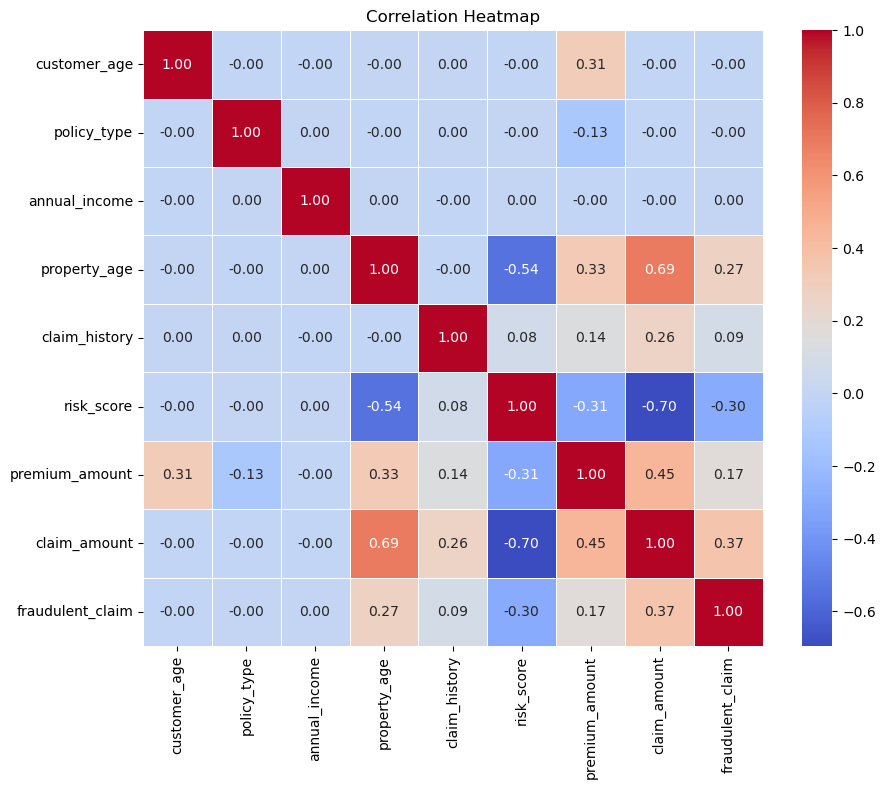

claim_amount        1.000000
property_age        0.692882
premium_amount      0.447747
fraudulent_claim    0.365236
claim_history       0.258444
policy_type        -0.001014
customer_age       -0.001503
annual_income      -0.002904
risk_score         -0.696060
Name: claim_amount, dtype: float64


In [14]:
#find the correlation between the features

df1 = df.drop(columns=["policy_id","gender"])

corr_matrix = df1.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()
corr_with_target = corr_matrix["claim_amount"].sort_values(ascending=False)
print(corr_with_target)

In [15]:
## Positive correlation with target variable (claim_amount)
# fraudulent_claim , property_age , claim_history , premium_amount

## Negetive correlation with target variable (claim_amount)
# risk_score

In [16]:
# Bivariant analysis

C:\Users\ragu\AppData\Local\Temp\ipykernel_1964\1515475816.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='property_age', y='claim_amount', data=df, errorbar=None, palette='viridis', legend=False)


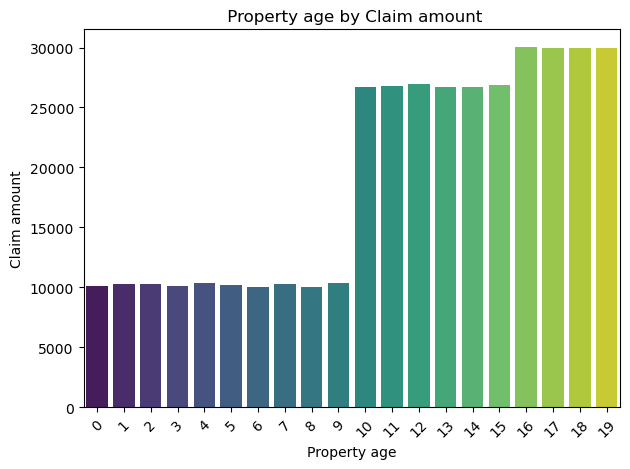

In [17]:
# Bar plot of average risk_score by policy_type
sns.barplot(x='property_age', y='claim_amount', data=df, errorbar=None, palette='viridis', legend=False)
plt.title(' Property age by Claim amount')
plt.xlabel('Property age')
plt.ylabel('Claim amount')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

C:\Users\ragu\AppData\Local\Temp\ipykernel_1964\524931393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fraudulent_claim', y='claim_amount', data=df, errorbar=None, palette='viridis', legend=False)


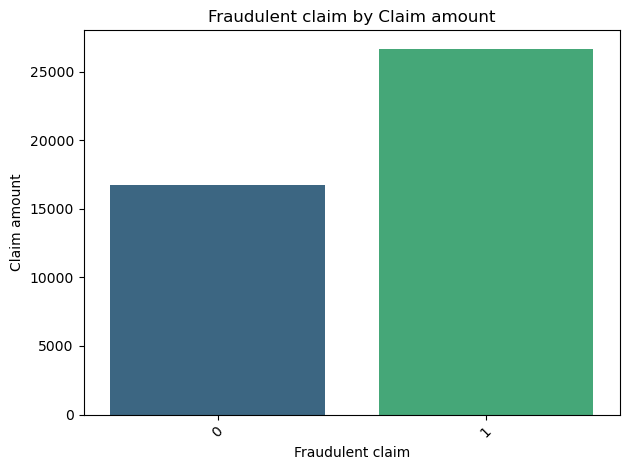

In [18]:
# Bar plot of average risk_score by policy_type
sns.barplot(x='fraudulent_claim', y='claim_amount', data=df, errorbar=None, palette='viridis', legend=False)
plt.title('Fraudulent claim by Claim amount')
plt.xlabel('Fraudulent claim')
plt.ylabel('Claim amount')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

C:\Users\ragu\AppData\Local\Temp\ipykernel_1964\1479076820.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='claim_history', y='claim_amount', data=df, errorbar=None, palette='viridis', legend=False)


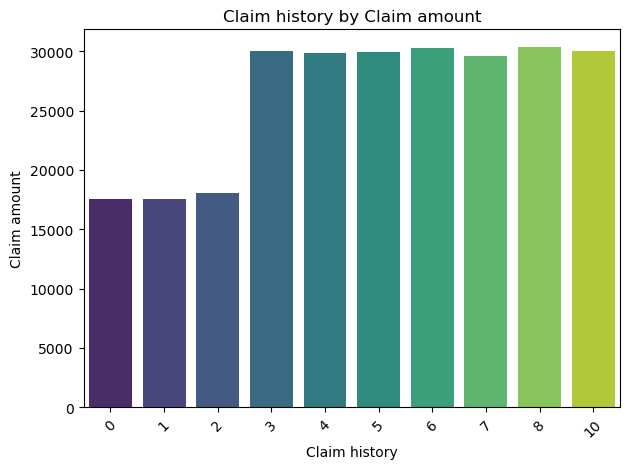

In [19]:

# Bar plot of average risk_score by policy_type
sns.barplot(x='claim_history', y='claim_amount', data=df, errorbar=None, palette='viridis', legend=False)
plt.title('Claim history by Claim amount')
plt.xlabel('Claim history')
plt.ylabel('Claim amount')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

C:\Users\ragu\AppData\Local\Temp\ipykernel_1964\1423648499.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_claim_by_bin = df.groupby('premium_bin')['claim_amount'].mean().reset_index()
C:\Users\ragu\AppData\Local\Temp\ipykernel_1964\1423648499.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='premium_bin', y='claim_amount', data=avg_claim_by_bin, palette='viridis')


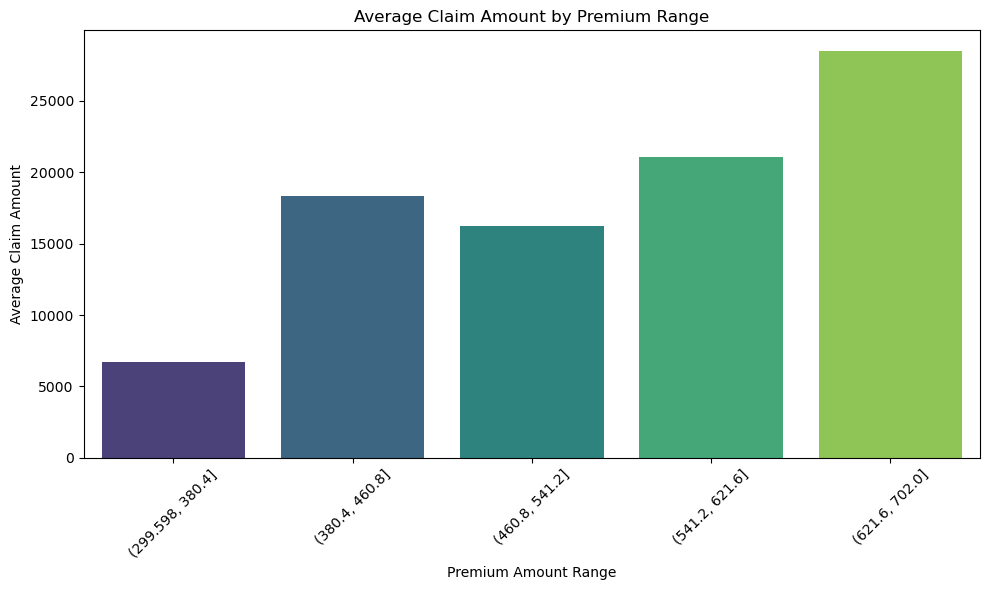

In [20]:
# Bin premium amounts into categories
df['premium_bin'] = pd.cut(df['premium_amount'], bins=5)

# Compute average claim per bin
avg_claim_by_bin = df.groupby('premium_bin')['claim_amount'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='premium_bin', y='claim_amount', data=avg_claim_by_bin, palette='viridis')
plt.title('Average Claim Amount by Premium Range')
plt.xlabel('Premium Amount Range')
plt.ylabel('Average Claim Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\ragu\AppData\Local\Temp\ipykernel_1964\214739736.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='risk_score', y='claim_amount', data=df, errorbar=None, palette='viridis', legend=False)


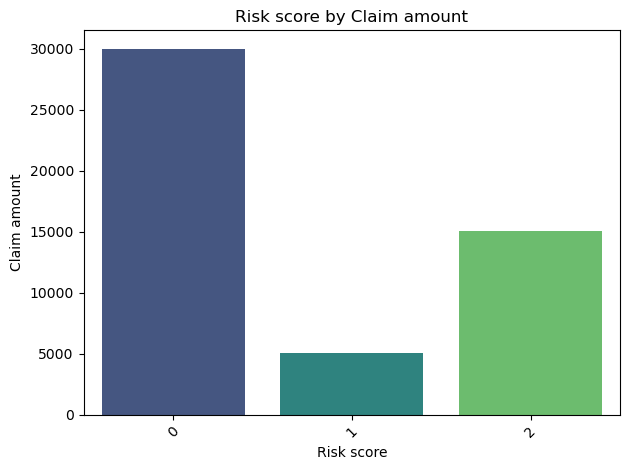

In [21]:
# Bar plot of average risk_score by policy_type
sns.barplot(x='risk_score', y='claim_amount', data=df, errorbar=None, palette='viridis', legend=False)
plt.title('Risk score by Claim amount')
plt.xlabel('Risk score')
plt.ylabel('Claim amount')
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

In [22]:
# Selected features
# fraudulent_claim , property_age , claim_history , premium_amount

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   policy_id         100000 non-null  object  
 1   customer_age      100000 non-null  int64   
 2   gender            100000 non-null  int32   
 3   policy_type       100000 non-null  int32   
 4   annual_income     100000 non-null  float64 
 5   property_age      100000 non-null  int64   
 6   claim_history     100000 non-null  int64   
 7   risk_score        100000 non-null  int32   
 8   premium_amount    100000 non-null  int64   
 9   claim_amount      100000 non-null  float64 
 10  fraudulent_claim  100000 non-null  int64   
 11  premium_bin       100000 non-null  category
dtypes: category(1), float64(2), int32(3), int64(5), object(1)
memory usage: 7.3+ MB


In [24]:
df.head()

,policy_id,customer_age,gender,policy_type,annual_income,property_age,claim_history,risk_score,premium_amount,claim_amount,fraudulent_claim,premium_bin
0,POL100000,56,0,1,91465.94,8,2,2,426,14134.62,0,"(380.4, 460.8]"
1,POL100001,69,0,3,99375.03,3,1,1,552,4075.14,0,"(541.2, 621.6]"
2,POL100002,46,1,1,79249.71,7,1,1,356,1382.87,0,"(299.598, 380.4]"
3,POL100003,32,1,0,78744.75,15,1,0,628,24902.32,0,"(621.6, 702.0]"
4,POL100004,60,1,2,51210.11,19,2,0,584,29411.28,1,"(541.2, 621.6]"


In [25]:
#Featues and target selection
x = df.drop(["policy_id", "claim_amount", "risk_score", "premium_bin"], axis=1)
y = df["claim_amount"]

In [26]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
# feature scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Model training 
model = LinearRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

In [28]:
# Model evaluation
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

5947.383257294364
53576451.77714206
0.6061444398033755


In [29]:
import sklearn.metrics as metrics

models = {
    "LinearRegression" : LinearRegression(),
    "Ridge" : Ridge(),
    "Lasso" : Lasso(),
    "ElasticNet" : ElasticNet()
}

result = []
for cls_name, model in models.items():
    trained_model = model.fit(x_train_scaled, y_train)
    y_pred = trained_model.predict(x_test_scaled)

    MAE = metrics.mean_absolute_error(y_test, y_pred)
    MSE = metrics.mean_squared_error(y_test, y_pred)
    RMSE = metrics.mean_squared_error(y_test, y_pred) ** 0.5
    R2 = metrics.r2_score(y_test, y_pred)

    result.append({"cls": cls_name, "mean_absolute_error": MAE, "mean_squared_error": MSE, "Root_mean_squared_error": RMSE, "r2_score": R2})

In [30]:
result = pd.DataFrame(result)
result

,cls,mean_absolute_error,mean_squared_error,Root_mean_squared_error,r2_score
0,LinearRegression,5947.383257,5.357645e+07,7319.593689,0.606144
1,Ridge,5947.386747,5.357644e+07,7319.592817,0.606145
2,Lasso,5947.433427,5.357617e+07,7319.574312,0.606147
3,ElasticNet,6497.199946,5.949920e+07,7713.572595,0.562605


In [31]:
# 1. Feature & target selection
X = df.drop(columns=["policy_id", "claim_amount", "risk_score", "premium_bin"])
y = df["claim_amount"]

In [32]:
# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [33]:
# 3. Identify column types
numeric_features = ["customer_age", "annual_income", "property_age", "claim_history", "premium_amount"]
categorical_features = ["gender", "policy_type", "fraudulent_claim"]


In [34]:
# 4. Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [35]:
# 5. Define models and parameters
models = {
    "Ridge": (Ridge(), {"model__alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso": (Lasso(max_iter=10000), {"model__alpha": [0.01, 0.1, 1, 10, 100]}),
}

In [36]:
# 6. Train and evaluate
for name, (model, params) in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    grid = GridSearchCV(pipe, param_grid=params, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)

    print(f"\n{name} Results on Test Set:")
    print(f"Best Params: {grid.best_params_}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"R² Score: {r2_score(y_test, y_pred):.4f}")


Ridge Results on Test Set:
Best Params: {'model__alpha': 0.01}
MAE: 2469.11
RMSE: 3086.04
R² Score: 0.9300

Lasso Results on Test Set:
Best Params: {'model__alpha': 0.1}
MAE: 2469.12
RMSE: 3086.04
R² Score: 0.9300


In [37]:
#Save model
#joblib.dump(grid.best_estimator_, "ridge_claim_model.pkl")

In [38]:
# Save the full pipeline
#joblib.dump(pipe, "amt_clim_.pkl")
#print("Model with preprocessing saved.")

In [51]:
# Load the full pipeline
model = joblib.load("C:/Users/ragu/capstone_pj/models/ridge_claim_model.pkl")

# Sample prediction
sample = {
    "customer_age": 45,
    "gender": 1,
    "policy_type": 1,
    "annual_income": 99249.71,
    "property_age": 8,
    "claim_history": 1,
    "premium_amount": 500,
    "fraudulent_claim": 0
}

import pandas as pd
sample_df = pd.DataFrame([sample])
prediction = model.predict(sample_df)
print(f"Predicted Claim Amount: ₹{prediction[0]:,.2f}")


Predicted Claim Amount: ₹41,296.71


In [52]:
df.head(5)

,policy_id,customer_age,gender,policy_type,annual_income,property_age,claim_history,risk_score,premium_amount,claim_amount,fraudulent_claim,premium_bin
0,POL100000,56,0,1,91465.94,8,2,2,426,14134.62,0,"(380.4, 460.8]"
1,POL100001,69,0,3,99375.03,3,1,1,552,4075.14,0,"(541.2, 621.6]"
2,POL100002,46,1,1,79249.71,7,1,1,356,1382.87,0,"(299.598, 380.4]"
3,POL100003,32,1,0,78744.75,15,1,0,628,24902.32,0,"(621.6, 702.0]"
4,POL100004,60,1,2,51210.11,19,2,0,584,29411.28,1,"(541.2, 621.6]"
